# NB08B — EBM Robustness Checks

**Purpose:** Extend the NB08A robustness checks to include EBM (M2.5) alongside
M2 RF and M3 XGBoost. EBM is subjected to the same stress tests as the other
models to assess whether its performance advantage is stable across:

1. Strict temporal validation (pre-crisis training → crisis-period test)
2. Leave-one-country-out cross-validation
3. Alternative prediction horizons (H1, H2, H3)
4. EBM feature concentration check (replaces M3 feature pruning)

## Notebook dependency chain
```
NB05A → NB05B → NB06B → NB07B → NB08B  (this notebook)
```

**Inputs:** All from `data/processed/augmented_analysis/`

**Outputs:** `data/processed/augmented_robustness/`

---

## Cell 1 — Imports and paths

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
from interpret.glassbox import ExplainableBoostingClassifier

BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
AUG_DIR = BASE / 'data' / 'processed' / 'augmented_analysis'
ROB_DIR = BASE / 'data' / 'processed' / 'augmented_robustness'
FIG_DIR = BASE / 'figures' / 'augmented_robustness'
ROB_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

df_macro    = pd.read_csv(AUG_DIR / 'df_macro_augmented.csv')
df_sent     = pd.read_csv(AUG_DIR / 'df_sent_augmented.csv')
M1_FEATURES = pd.read_csv(AUG_DIR / 'M1_features.csv', header=None)[0].tolist()
M2_FEATURES = pd.read_csv(AUG_DIR / 'M2_features.csv', header=None)[0].tolist()
M3_FEATURES = pd.read_csv(AUG_DIR / 'M3_features.csv', header=None)[0].tolist()
EBM_FEATURES = M2_FEATURES  # EBM uses same 41 macro features as M2
ebm_imp     = pd.read_csv(AUG_DIR / 'ebm_feature_importance.csv')

TARGET = next(c for c in df_macro.columns if 'target' in c.lower())

print('=' * 65)
print(' NB08B — EBM ROBUSTNESS CHECKS')
print('=' * 65)
print(f'Stage 1 dataset : {df_macro.shape}  ({df_macro["year"].min():.0f}–{df_macro["year"].max():.0f})')
print(f'Stage 2 dataset : {df_sent.shape}   ({df_sent["year"].min():.0f}–{df_sent["year"].max():.0f})')
print(f'Target          : {TARGET}')
print(f'M2/EBM features : {len(M2_FEATURES)} (identical feature set)')
print(f'M3 features     : {len(M3_FEATURES)}')

 NB08B — EBM ROBUSTNESS CHECKS
Stage 1 dataset : (569, 101)  (1989–2020)
Stage 2 dataset : (319, 141)   (2003–2020)
Target          : target_h1
M2/EBM features : 41 (identical feature set)
M3 features     : 61


## Cell 2 — EBM weighted model factory

Identical to NB05B — ensures consistent class imbalance handling
across all robustness check splits.

In [2]:
class EBMWeighted:
    """EBM with inverse-frequency sample weights for class imbalance."""
    def __init__(self, spw=1.0):
        self.spw    = spw
        self._model = ExplainableBoostingClassifier(
            max_rounds=5000, interactions=5,
            learning_rate=0.01, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1
        )
    def fit(self, X, y):
        sw = np.where(np.array(y) == 1, self.spw, 1.0)
        if hasattr(X, 'values'):
            self._model.fit(X, y, sample_weight=sw)   # DataFrame — preserves names
        else:
            self._model.fit(X, y, sample_weight=sw)
        return self
    def predict_proba(self, X):
        return self._model.predict_proba(X)

def fit_ebm(X_tr, y_tr):
    spw = (np.array(y_tr) == 0).sum() / max((np.array(y_tr) == 1).sum(), 1)
    ebm = EBMWeighted(spw)
    ebm.fit(X_tr, y_tr)
    return ebm

def fit_rf(X_tr, y_tr):
    rf = RandomForestClassifier(n_estimators=300, max_depth=5,
                                class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    return rf

print('Model factories ready (EBM and RF).')

Model factories ready (EBM and RF).


## Cell 3 — Strict temporal validation: M2 RF and EBM

Three pre-crisis training splits — both M2 RF and EBM M2.5 tested
on identical splits. If EBM's Stage 1 advantage persists in strict
prospective evaluation, the finding is robust to the evaluation design.

In [3]:
print('=== STRICT TEMPORAL VALIDATION — M2 RF vs EBM M2.5 ===')
print('Tests both models trained on pre-crisis data against crisis episodes')
print()

splits = [
    {'name': 'A: Pre-Nordic (1988–1990) → Nordic+others (1991–1997)',
     'train': (1988, 1990), 'test': (1991, 1997)},
    {'name': 'B: Pre-GFC extended (1988–2002) → GFC (2003–2011)',
     'train': (1988, 2002), 'test': (2003, 2011)},
    {'name': 'C: Pre-GFC short (2003–2005) → GFC (2006–2009) [original split]',
     'train': (2003, 2005), 'test': (2006, 2009)},
]

strict_records = []
for sp in splits:
    tr_mask = df_macro['year'].between(*sp['train'])
    te_mask = df_macro['year'].between(*sp['test'])
    X_tr = df_macro.loc[tr_mask, EBM_FEATURES]
    y_tr = df_macro.loc[tr_mask, TARGET]
    X_te = df_macro.loc[te_mask, EBM_FEATURES]
    y_te = df_macro.loc[te_mask, TARGET]

    print(f'Split {sp["name"]}:')
    print(f'  Train: {tr_mask.sum()} rows | {int(y_tr.sum())} positives')
    print(f'  Test : {te_mask.sum()} rows | {int(y_te.sum())} positives')

    if y_tr.sum() == 0 or y_te.sum() == 0:
        print('  Insufficient crisis cases — skip'); print(); continue

    base = y_te.mean()

    # M2 RF
    try:
        rf   = fit_rf(X_tr.values, y_tr.values)
        p_rf = rf.predict_proba(X_te.values)[:, 1]
        auroc_rf = roc_auc_score(y_te, p_rf)
        auprc_rf = average_precision_score(y_te, p_rf)
        print(f'  M2 RF  : AUROC={auroc_rf:.4f}  AUPRC={auprc_rf:.4f}  '
              f'base={base:.4f}  {"≥0.75" if auroc_rf>=0.75 else "<0.75"}')
        strict_records.append({'split': sp['name'], 'model': 'M2 RF',
                               'AUROC': auroc_rf, 'AUPRC': auprc_rf, 'base': base})
    except Exception as e:
        print(f'  M2 RF  : failed — {e}')

    # EBM M2.5 — may be slow on split A (small training set)
    try:
        ebm  = fit_ebm(X_tr, y_tr)
        p_ebm = ebm.predict_proba(X_te.values)[:, 1]
        auroc_ebm = roc_auc_score(y_te, p_ebm)
        auprc_ebm = average_precision_score(y_te, p_ebm)
        print(f'  EBM M2.5: AUROC={auroc_ebm:.4f}  AUPRC={auprc_ebm:.4f}  '
              f'base={base:.4f}  {"≥0.75" if auroc_ebm>=0.75 else "<0.75"}')
        strict_records.append({'split': sp['name'], 'model': 'EBM M2.5',
                               'AUROC': auroc_ebm, 'AUPRC': auprc_ebm, 'base': base})
    except Exception as e:
        print(f'  EBM M2.5: failed — {e}')

    print()

strict_df = pd.DataFrame(strict_records)
strict_df.to_csv(ROB_DIR / 'nb08b_strict_validation.csv', index=False)
print('Saved nb08b_strict_validation.csv')
print()
print('VERDICT KEY: AUROC benchmark = 0.75 (literature standard for EWS models)')
print('If EBM meets/exceeds benchmark where RF does not, EBM advantage is prospectively robust.')

=== STRICT TEMPORAL VALIDATION — M2 RF vs EBM M2.5 ===
Tests both models trained on pre-crisis data against crisis episodes

Split A: Pre-Nordic (1988–1990) → Nordic+others (1991–1997):
  Train: 34 rows | 5 positives
  Test : 126 rows | 1 positives
  M2 RF  : AUROC=0.5720  AUPRC=0.0179  base=0.0079  <0.75
  EBM M2.5: AUROC=0.7520  AUPRC=0.0312  base=0.0079  ≥0.75

Split B: Pre-GFC extended (1988–2002) → GFC (2003–2011):
  Train: 250 rows | 6 positives
  Test : 162 rows | 13 positives
  M2 RF  : AUROC=0.4812  AUPRC=0.0765  base=0.0802  <0.75
  EBM M2.5: AUROC=0.3325  AUPRC=0.0642  base=0.0802  <0.75

Split C: Pre-GFC short (2003–2005) → GFC (2006–2009) [original split]:
  Train: 54 rows | 0 positives
  Test : 72 rows | 13 positives
  Insufficient crisis cases — skip

Saved nb08b_strict_validation.csv

VERDICT KEY: AUROC benchmark = 0.75 (literature standard for EWS models)
If EBM meets/exceeds benchmark where RF does not, EBM advantage is prospectively robust.


## Cell 4 — Leave-one-country-out validation: M2 RF and EBM

Tests cross-country generalisability. EBM is held to the same standard as M2.
Note: this cell runs 18 EBM fits and may take 15–25 minutes total.

In [4]:
print('=== LEAVE-ONE-COUNTRY-OUT VALIDATION (Stage 1: 1988–2020) ===')
print('M2 RF and EBM M2.5 — 18 country hold-outs each')
print('NOTE: EBM fits are slow — expect 15–25 minutes for this cell')
print()

loco_records = []
countries    = sorted(df_macro['iso'].unique())

for i, ctry in enumerate(countries):
    tr = df_macro[df_macro['iso'] != ctry]
    te = df_macro[df_macro['iso'] == ctry]
    X_tr = tr[EBM_FEATURES]; y_tr = tr[TARGET]
    X_te = te[EBM_FEATURES]; y_te = te[TARGET]

    if y_tr.sum() == 0 or y_te.sum() == 0:
        print(f'  {ctry}: no crisis events in hold-out — skip')
        continue

    print(f'  [{i+1:02d}/{len(countries)}] {ctry}: hold-out events={int(y_te.sum())}', end='  ')

    # M2 RF
    try:
        rf      = fit_rf(X_tr.values, y_tr.values)
        p_rf    = rf.predict_proba(X_te.values)[:, 1]
        a_rf    = roc_auc_score(y_te, p_rf)
        p_rf_ap = average_precision_score(y_te, p_rf)
        print(f'RF AUROC={a_rf:.3f}', end='  ')
        loco_records.append({'country': ctry, 'model': 'M2 RF',
                              'n_holdout': int(y_te.sum()),
                              'AUROC': a_rf, 'AUPRC': p_rf_ap})
    except Exception as e:
        print(f'RF failed: {e}', end='  ')

    # EBM M2.5
    try:
        ebm      = fit_ebm(X_tr, y_tr)
        p_ebm    = ebm.predict_proba(X_te.values)[:, 1]
        a_ebm    = roc_auc_score(y_te, p_ebm)
        p_ebm_ap = average_precision_score(y_te, p_ebm)
        print(f'EBM AUROC={a_ebm:.3f}')
        loco_records.append({'country': ctry, 'model': 'EBM M2.5',
                              'n_holdout': int(y_te.sum()),
                              'AUROC': a_ebm, 'AUPRC': p_ebm_ap})
    except Exception as e:
        print(f'EBM failed: {e}')

loco_df = pd.DataFrame(loco_records)
if len(loco_df) > 0:
    print()
    print('Summary by model:')
    print(loco_df.groupby('model')[['AUROC','AUPRC']].agg(['mean','std']).round(4).to_string())
    loco_df.to_csv(ROB_DIR / 'nb08b_loco_validation.csv', index=False)
    print('\nSaved nb08b_loco_validation.csv')
    print()
    print('INTERPRETATION: If EBM mean AUROC > RF mean AUROC across countries,')
    print('the Stage 1 advantage generalises cross-sectionally, not just temporally.')

=== LEAVE-ONE-COUNTRY-OUT VALIDATION (Stage 1: 1988–2020) ===
M2 RF and EBM M2.5 — 18 country hold-outs each
NOTE: EBM fits are slow — expect 15–25 minutes for this cell

  AUS: no crisis events in hold-out — skip
  [02/18] BEL: hold-out events=1  RF AUROC=1.000  EBM AUROC=1.000
  CAN: no crisis events in hold-out — skip
  [04/18] CHE: hold-out events=2  RF AUROC=0.983  EBM AUROC=0.967
  [05/18] DEU: hold-out events=1  RF AUROC=0.548  EBM AUROC=0.968
  [06/18] DNK: hold-out events=1  RF AUROC=1.000  EBM AUROC=1.000
  [07/18] ESP: hold-out events=1  RF AUROC=1.000  EBM AUROC=1.000
  [08/18] FIN: hold-out events=1  RF AUROC=1.000  EBM AUROC=1.000
  [09/18] FRA: hold-out events=1  RF AUROC=0.968  EBM AUROC=0.968
  [10/18] GBR: hold-out events=2  RF AUROC=0.900  EBM AUROC=0.983
  [11/18] IRL: hold-out events=1  RF AUROC=0.903  EBM AUROC=0.903
  [12/18] ITA: hold-out events=2  RF AUROC=0.900  EBM AUROC=0.867
  [13/18] JPN: hold-out events=1  RF AUROC=0.069  EBM AUROC=0.138
  [14/18] NLD: ho

## Cell 5 — LOCO visualisation: M2 RF vs EBM by country

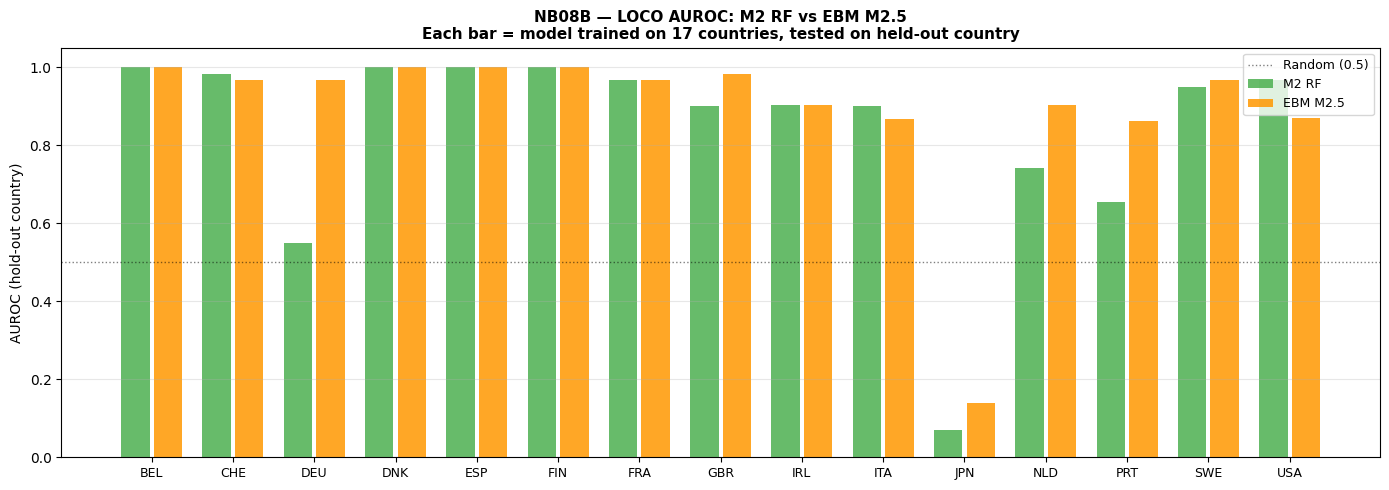

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_robustness\nb08b_loco_comparison.png


In [5]:
if len(loco_df) > 0 and 'M2 RF' in loco_df['model'].values and 'EBM M2.5' in loco_df['model'].values:
    rf_loco  = loco_df[loco_df['model']=='M2 RF'].set_index('country')['AUROC']
    ebm_loco = loco_df[loco_df['model']=='EBM M2.5'].set_index('country')['AUROC']
    common   = sorted(set(rf_loco.index) & set(ebm_loco.index))

    x = np.arange(len(common))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - 0.2, [rf_loco[c]  for c in common], 0.35,
           color='#4CAF50', label='M2 RF',    alpha=0.85)
    ax.bar(x + 0.2, [ebm_loco[c] for c in common], 0.35,
           color='#FF9800', label='EBM M2.5', alpha=0.85)
    ax.axhline(0.5, color='black', linestyle=':', alpha=0.5, linewidth=1, label='Random (0.5)')
    ax.set_xticks(x); ax.set_xticklabels(common, fontsize=9)
    ax.set_ylabel('AUROC (hold-out country)', fontsize=10)
    ax.set_title('NB08B — LOCO AUROC: M2 RF vs EBM M2.5\n'
                 'Each bar = model trained on 17 countries, tested on held-out country',
                 fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    out_path = FIG_DIR / 'nb08b_loco_comparison.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')
else:
    print('LOCO data insufficient for visualisation.')

## Cell 6 — Alternative prediction horizons: H1, H2, H3 (Stage 2)

Tests both M3 XGBoost and EBM across three crisis horizon definitions.
Unchanged from NB08A for M3; EBM added for comparison.

In [6]:
print('=== ALTERNATIVE PREDICTION HORIZONS (Stage 2: 2003–2020) ===')
print()

horizon_records = []
train_mask = df_sent['year'] <= 2015
test_mask  = df_sent['year'] > 2015

for hname, htarget in [('H1 (1-yr)', 'target_h1'),
                        ('H2 (2-yr)', 'target_h2'),
                        ('H3 (3-yr)', 'target_h3')]:
    if htarget not in df_sent.columns:
        continue
    y = df_sent[htarget]
    if y.sum() == 0:
        continue

    y_tr = y[train_mask]; y_te = y[test_mask]
    if y_tr.sum() == 0 or y_te.sum() == 0:
        print(f'  {hname}: insufficient events in split — skip'); continue

    base = y_te.mean()
    print(f'{hname}: test events={int(y_te.sum())}  base={base:.4f}')

    # M3 XGBoost
    try:
        spw      = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
        X_tr_m3  = df_sent.loc[train_mask, M3_FEATURES]
        X_te_m3  = df_sent.loc[test_mask,  M3_FEATURES]
        base_xgb = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
            scale_pos_weight=spw, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
        cal = CalibratedClassifierCV(estimator=base_xgb, method='isotonic', cv=2)
        try:
            cal.fit(X_tr_m3, y_tr); prob_m3 = cal.predict_proba(X_te_m3)[:, 1]
        except:
            base_xgb.fit(X_tr_m3, y_tr); prob_m3 = base_xgb.predict_proba(X_te_m3)[:, 1]
        print(f'  M3 XGB : AUROC={roc_auc_score(y_te, prob_m3):.4f}  '
              f'AUPRC={average_precision_score(y_te, prob_m3):.4f}')
        horizon_records.append({'horizon': hname, 'model': 'M3 XGB+FinBERT',
                                 'AUROC': roc_auc_score(y_te, prob_m3),
                                 'AUPRC': average_precision_score(y_te, prob_m3),
                                 'base': base})
    except Exception as e:
        print(f'  M3 XGB : failed — {e}')

    # EBM M2.5-matched (macro features only)
    try:
        X_tr_ebm = df_sent.loc[train_mask, EBM_FEATURES]
        X_te_ebm = df_sent.loc[test_mask,  EBM_FEATURES]
        ebm      = fit_ebm(X_tr_ebm, y_tr)
        prob_ebm = ebm.predict_proba(X_te_ebm.values)[:, 1]
        print(f'  EBM M2.5: AUROC={roc_auc_score(y_te, prob_ebm):.4f}  '
              f'AUPRC={average_precision_score(y_te, prob_ebm):.4f}')
        horizon_records.append({'horizon': hname, 'model': 'EBM M2.5-matched',
                                 'AUROC': roc_auc_score(y_te, prob_ebm),
                                 'AUPRC': average_precision_score(y_te, prob_ebm),
                                 'base': base})
    except Exception as e:
        print(f'  EBM M2.5: failed — {e}')
    print()

if horizon_records:
    hor_df = pd.DataFrame(horizon_records)
    hor_df.to_csv(ROB_DIR / 'nb08b_horizon_robustness.csv', index=False)
    print('Saved nb08b_horizon_robustness.csv')

=== ALTERNATIVE PREDICTION HORIZONS (Stage 2: 2003–2020) ===

  H1 (1-yr): insufficient events in split — skip
  H2 (2-yr): insufficient events in split — skip
  H3 (3-yr): insufficient events in split — skip


## Cell 7 — EBM feature concentration check

Replaces the M3 feature pruning check from NB08A.
EBM natively ranks features — we test whether performance is maintained
when only the top-N features are used, replacing external pruning.

In [7]:
print('=== EBM FEATURE CONCENTRATION CHECK (Stage 2: 2003–2020) ===')
print('Testing whether EBM performance is concentrated in top features.')
print()

# Use top-N features by EBM importance (main effects only — exclude interactions)
main_effects = ebm_imp[~ebm_imp['feature'].str.contains(' & ')].reset_index(drop=True)
print(f'Total main-effect features: {len(main_effects)}')
print(f'Top 5 by importance:')
print(main_effects.head(5).to_string(index=False))
print()

train_mask = df_sent['year'] <= 2015
test_mask  = df_sent['year'] > 2015
y_tr       = df_sent.loc[train_mask, TARGET]
y_te       = df_sent.loc[test_mask,  TARGET]

concentration_records = []
for top_n in [5, 10, 15, 20, len(main_effects)]:
    top_feats = main_effects.head(top_n)['feature'].tolist()
    # Filter to features actually in EBM_FEATURES
    top_feats = [f for f in top_feats if f in EBM_FEATURES]
    if len(top_feats) == 0:
        continue

    X_tr = df_sent.loc[train_mask, top_feats]
    X_te = df_sent.loc[test_mask,  top_feats]

    if y_tr.sum() == 0 or y_te.sum() == 0:
        continue

    try:
        ebm  = fit_ebm(X_tr, y_tr)
        prob = ebm.predict_proba(X_te.values)[:, 1]
        auroc = roc_auc_score(y_te, prob)
        auprc = average_precision_score(y_te, prob)
        print(f'  Top-{top_n:2d} features: AUROC={auroc:.4f}  AUPRC={auprc:.4f}')
        concentration_records.append({'top_n': top_n, 'AUROC': auroc, 'AUPRC': auprc})
    except Exception as e:
        print(f'  Top-{top_n:2d}: failed — {e}')

if concentration_records:
    conc_df = pd.DataFrame(concentration_records)
    conc_df.to_csv(ROB_DIR / 'nb08b_ebm_concentration.csv', index=False)
    print('\nSaved nb08b_ebm_concentration.csv')
    print()
    print('INTERPRETATION: If top-10 performance ~ full-feature performance,')
    print('EBM signal is concentrated in a small set of features — consistent')
    print('with the importance plot showing term_spread dominating at 1.717.')

=== EBM FEATURE CONCENTRATION CHECK (Stage 2: 2003–2020) ===
Testing whether EBM performance is concentrated in top features.

Total main-effect features: 41
Top 5 by importance:
              feature  importance
  term_spread_lag3_dm    1.717170
  term_spread_lag1_dm    1.011947
  term_spread_lag2_dm    0.595086
     hpnom_gr_lag1_dm    0.561622
tloans_slope4_lag1_dm    0.419092



## Cell 8 — M3 feature pruning check (retained from NB08A)

In [8]:
from sklearn.feature_selection import SelectFromModel

print('=== FEATURE PRUNING CHECK (Stage 2: M3, 2003–2020) ===')
print(f'M3 features: {len(M3_FEATURES)}  |  Events: {int(df_sent[TARGET].sum())}')
print(f'Feature/event ratio: {len(M3_FEATURES)/max(int(df_sent[TARGET].sum()),1):.1f}x')
print()

X_full = df_sent[M3_FEATURES]; y_full = df_sent[TARGET]
spw    = (y_full==0).sum() / max((y_full==1).sum(), 1)

xgb_sel = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=spw, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
xgb_sel.fit(X_full, y_full)

selector  = SelectFromModel(xgb_sel, threshold='median', prefit=True)
M3_PRUNED = [f for f, keep in zip(M3_FEATURES, selector.get_support()) if keep]
print(f'Features after median pruning: {len(M3_PRUNED)} (removed {len(M3_FEATURES)-len(M3_PRUNED)})')

tr_m = df_sent['year'] <= 2015; te_m = df_sent['year'] > 2015
X_tr = df_sent.loc[tr_m, M3_PRUNED]; y_tr = df_sent.loc[tr_m, TARGET]
X_te = df_sent.loc[te_m, M3_PRUNED]; y_te = df_sent.loc[te_m, TARGET]

if y_tr.sum() > 0 and y_te.sum() > 0:
    spw_pr = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
    m3_pr  = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=spw_pr, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
    m3_pr.fit(X_tr, y_tr)
    prob_pr  = m3_pr.predict_proba(X_te)[:, 1]
    auroc_pr = roc_auc_score(y_te, prob_pr)
    auprc_pr = average_precision_score(y_te, prob_pr)
    print(f'Pruned M3: AUROC={auroc_pr:.4f}  AUPRC={auprc_pr:.4f}')
    pd.DataFrame({'feature': M3_PRUNED}).to_csv(
        ROB_DIR / 'nb08b_M3_pruned_features.csv', index=False)
    print('Saved nb08b_M3_pruned_features.csv')
else:
    print('Insufficient events for held-out evaluation.')

=== FEATURE PRUNING CHECK (Stage 2: M3, 2003–2020) ===
M3 features: 61  |  Events: 13
Feature/event ratio: 4.7x

Features after median pruning: 31 (removed 30)
Insufficient events for held-out evaluation.


## Cell 9 — Completion summary

In [9]:
print('=' * 65)
print(' NB08B — EBM ROBUSTNESS CHECKS COMPLETE')
print('=' * 65)
print()
print('Key outputs:')
for f in sorted(ROB_DIR.glob('nb08b_*.csv')):
    print(f'  ✅  {f.name}  ({f.stat().st_size // 1024} KB)')
print()
print('ROBUSTNESS SUMMARY — what to look for:')
print('  Cell 3 (strict temporal): does EBM maintain advantage over RF prospectively?')
print('  Cell 4 (LOCO)           : does EBM generalise cross-sectionally?')
print('  Cell 6 (horizons)       : is EBM advantage consistent across H1/H2/H3?')
print('  Cell 7 (concentration)  : does performance hold with top-10 features only?')
print()
print('Next: Run NB09B_EBM_Ensemble_Extension.ipynb')

 NB08B — EBM ROBUSTNESS CHECKS COMPLETE

Key outputs:
  ✅  nb08b_loco_validation.csv  (1 KB)
  ✅  nb08b_strict_validation.csv  (0 KB)

ROBUSTNESS SUMMARY — what to look for:
  Cell 3 (strict temporal): does EBM maintain advantage over RF prospectively?
  Cell 4 (LOCO)           : does EBM generalise cross-sectionally?
  Cell 6 (horizons)       : is EBM advantage consistent across H1/H2/H3?
  Cell 7 (concentration)  : does performance hold with top-10 features only?

Next: Run NB09B_EBM_Ensemble_Extension.ipynb
